In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats
from utils.udp_util import extract_udp_prague_to_dataframe

In [2]:
# Load data
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"

graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/server_data', mainpth+'/client1_data', mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '')


# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')




Directory already exists: ../data/udp_data_2025-04-27\Graphs
Directory already exists: ../data/udp_data_2025-04-27\Stats
Unique Mbps and ms Combinations:
10 Mbps, 0 ms
10 Mbps, 10 ms
10 Mbps, 20 ms
10 Mbps, 5 ms
100 Mbps, 0 ms
100 Mbps, 10 ms
100 Mbps, 20 ms
100 Mbps, 5 ms
150 Mbps, 0 ms
150 Mbps, 10 ms
150 Mbps, 20 ms
150 Mbps, 5 ms
20 Mbps, 0 ms
20 Mbps, 10 ms
20 Mbps, 20 ms
20 Mbps, 5 ms
5 Mbps, 0 ms
5 Mbps, 10 ms
5 Mbps, 20 ms
5 Mbps, 5 ms


In [3]:
unique_scenarios_dict_v2 = {}
for mbps, ms in unique_combinations:
    scenario_search = f"{mbps}Mbps_{ms}ms"
    for index in range(len(filenames)):
        if scenario_search in filenames[index]:
            print(f"Found {scenario_search} in {filenames[index]}")
            if scenario_search in unique_scenarios_dict_v2:
                unique_scenarios_dict_v2[scenario_search].append(filedict[filenames[index]])
            else:
                unique_scenarios_dict_v2[scenario_search]=[filedict[filenames[index]]]
            


Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_dsthost.em1.pcap
Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_dsthost.siftr.log
Found 20Mbps_0ms in 2_dualpi2_20Mbps_0ms_ecn_udp_dsthost.em1.pcap
Found 20Mbps_0ms in 2_dualpi2_20Mbps_0ms_ecn_udp_dsthost.siftr.log
Found 20Mbps_0ms in udp_prague_receiver_1_dualpi2_20Mbps_0ms_ecn_udp.txt
Found 20Mbps_0ms in udp_prague_receiver_2_dualpi2_20Mbps_0ms_ecn_udp.txt
Found 20Mbps_0ms in udp_prague_sender_1_dualpi2_20Mbps_0ms_ecn_udp.txt
Found 20Mbps_0ms in udp_prague_sender_2_dualpi2_20Mbps_0ms_ecn_udp.txt
Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_cubic_src1.em1.pcap
Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_cubic_src1.siftr.log
Found 20Mbps_0ms in 2_dualpi2_20Mbps_0ms_ecn_udp_cubic_src1.em1.pcap
Found 20Mbps_0ms in 2_dualpi2_20Mbps_0ms_ecn_udp_cubic_src1.siftr.log
Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.em1.pcap
Found 20Mbps_0ms in 1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
Found 20Mbps_0ms in 2_dualpi2

In [4]:
unique_scenarios_dict_v2['100Mbps_10ms']

['../data/udp_data_2025-04-27/server_data\\1_dualpi2_100Mbps_10ms_ecn_udp_dsthost.em1.pcap',
 '../data/udp_data_2025-04-27/server_data\\1_dualpi2_100Mbps_10ms_ecn_udp_dsthost.siftr.log',
 '../data/udp_data_2025-04-27/server_data\\2_dualpi2_100Mbps_10ms_ecn_udp_dsthost.em1.pcap',
 '../data/udp_data_2025-04-27/server_data\\2_dualpi2_100Mbps_10ms_ecn_udp_dsthost.siftr.log',
 '../data/udp_data_2025-04-27/server_data\\udp_prague_receiver_1_dualpi2_100Mbps_10ms_ecn_udp.txt',
 '../data/udp_data_2025-04-27/server_data\\udp_prague_receiver_2_dualpi2_100Mbps_10ms_ecn_udp.txt',
 '../data/udp_data_2025-04-27/server_data\\udp_prague_sender_1_dualpi2_100Mbps_10ms_ecn_udp.txt',
 '../data/udp_data_2025-04-27/server_data\\udp_prague_sender_2_dualpi2_100Mbps_10ms_ecn_udp.txt',
 '../data/udp_data_2025-04-27/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_cubic_src1.em1.pcap',
 '../data/udp_data_2025-04-27/client1_data\\1_dualpi2_100Mbps_10ms_ecn_udp_cubic_src1.siftr.log',
 '../data/udp_data_2025-04-27/clien

In [5]:
from utils.plotter import  plot_siftr_graph


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_20Mbps_0ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_0ms_ecn_udp_dctcp_src2.siftr.log


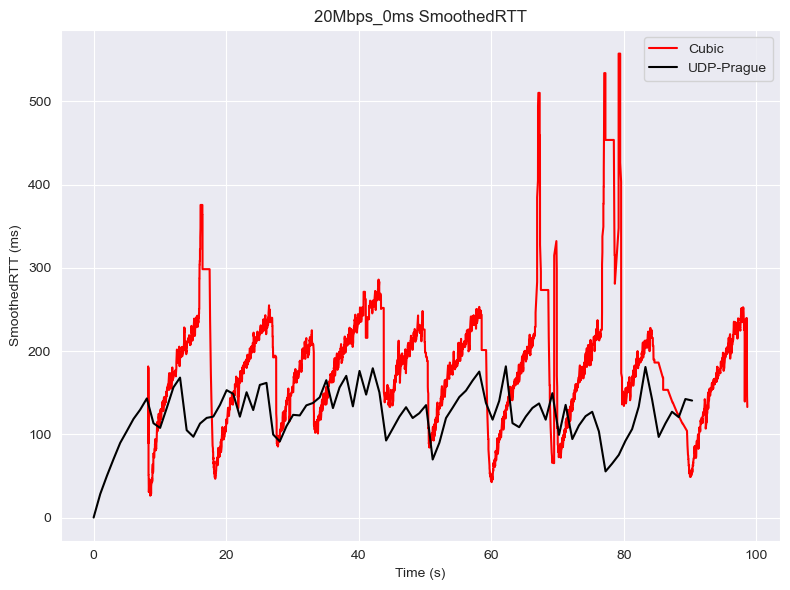


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_150Mbps_20ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_20ms_ecn_udp_dctcp_src2.siftr.log


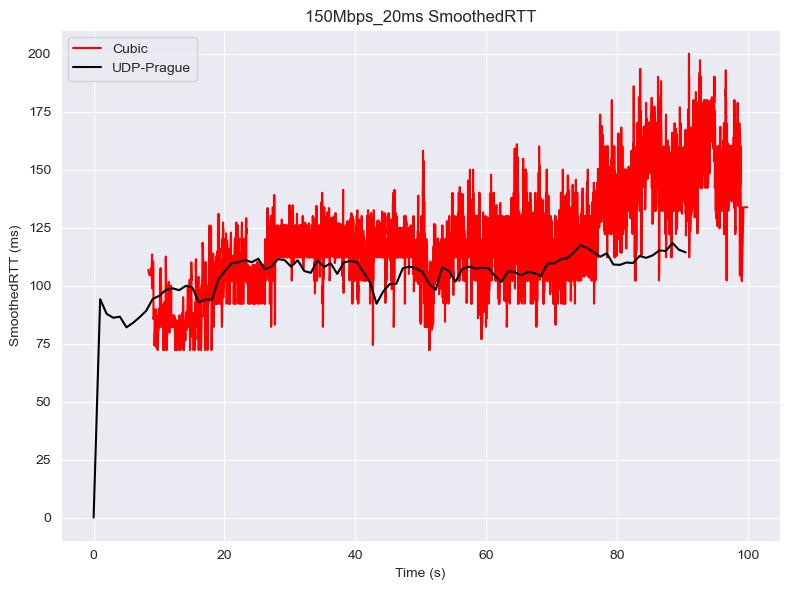


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_150Mbps_0ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_0ms_ecn_udp_dctcp_src2.siftr.log


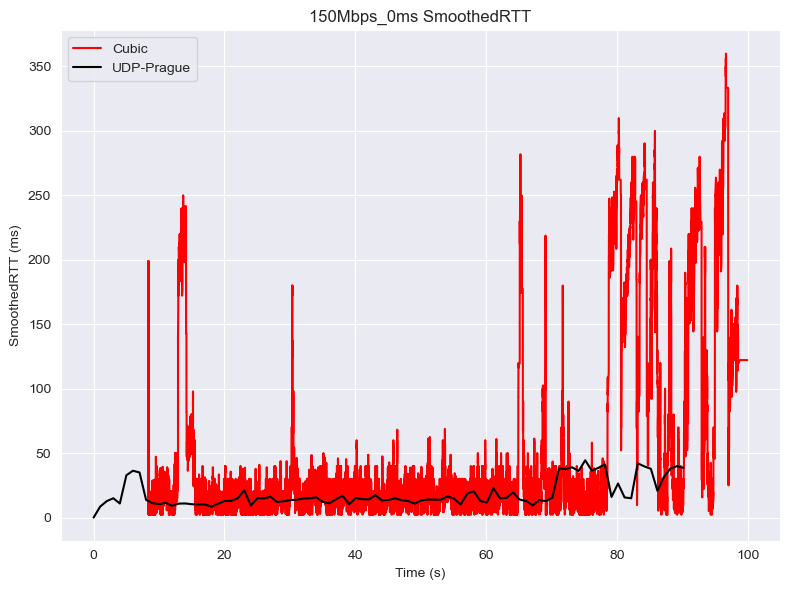


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_10Mbps_5ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_5ms_ecn_udp_dctcp_src2.siftr.log


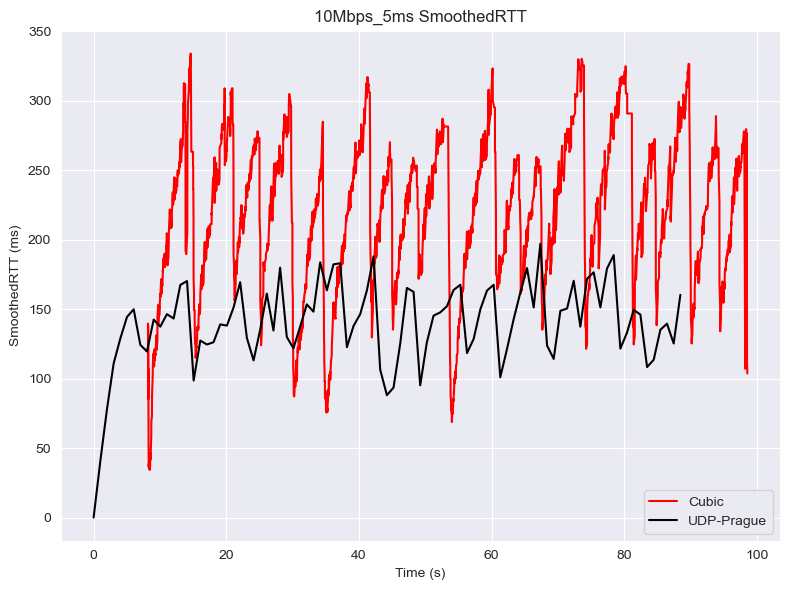


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_100Mbps_5ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_5ms_ecn_udp_dctcp_src2.siftr.log


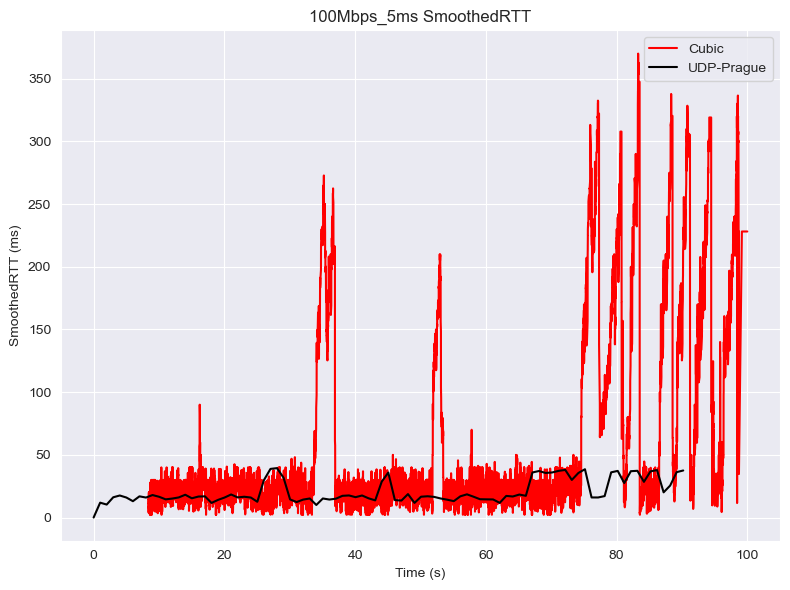


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_5Mbps_10ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


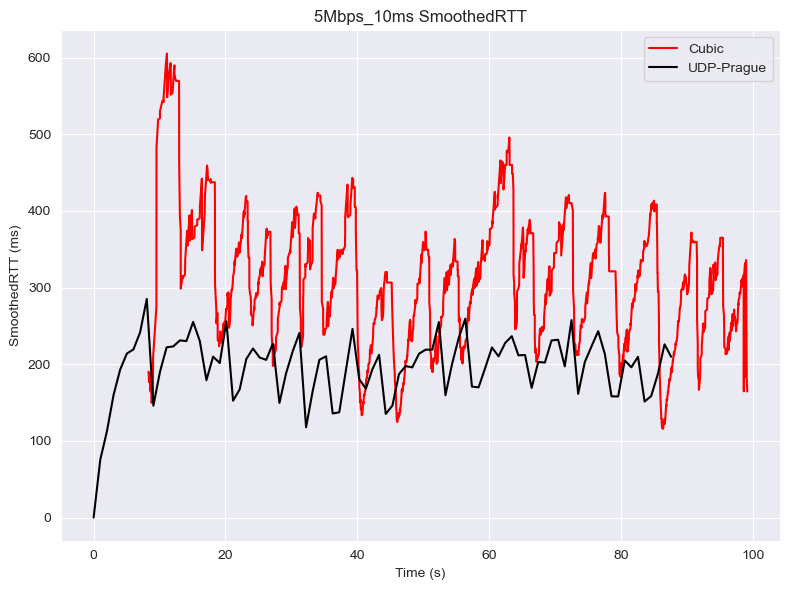


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_20Mbps_10ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


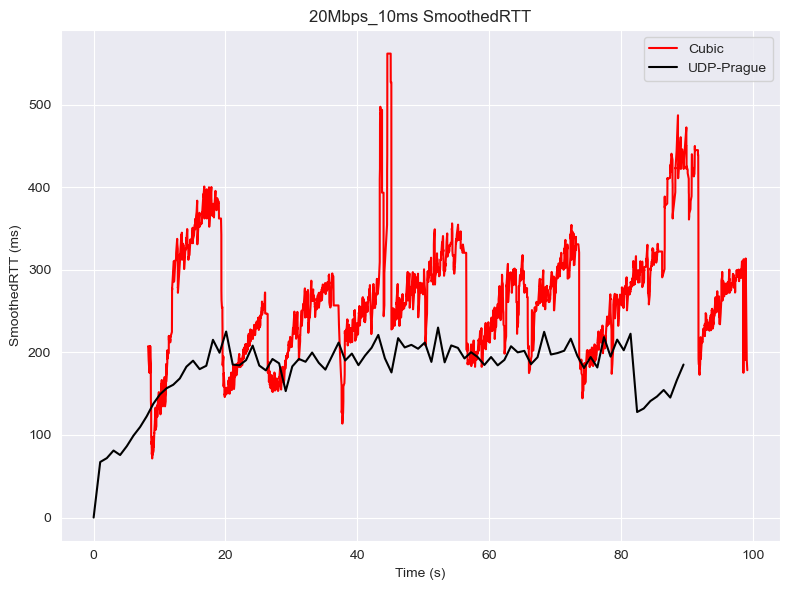


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_10Mbps_20ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_20ms_ecn_udp_dctcp_src2.siftr.log


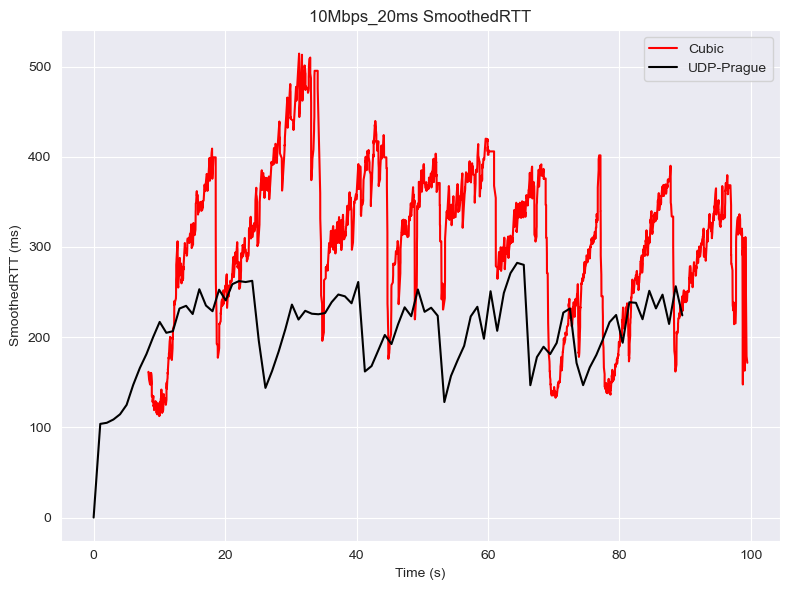


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_150Mbps_10ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


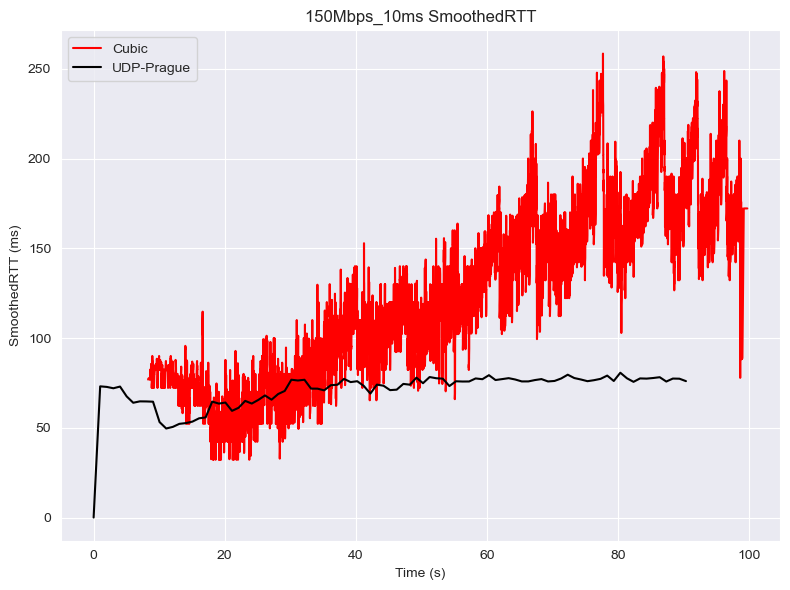


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_10Mbps_0ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_0ms_ecn_udp_dctcp_src2.siftr.log


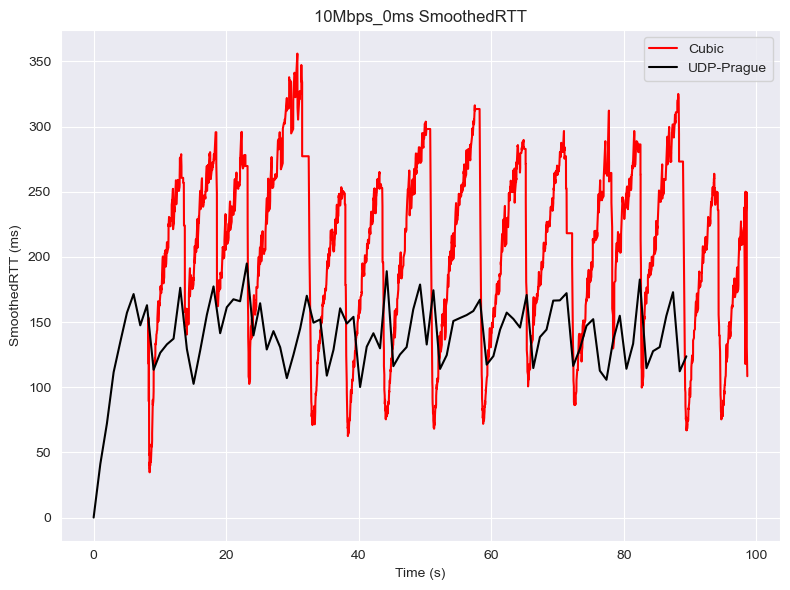


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_100Mbps_20ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_20ms_ecn_udp_dctcp_src2.siftr.log


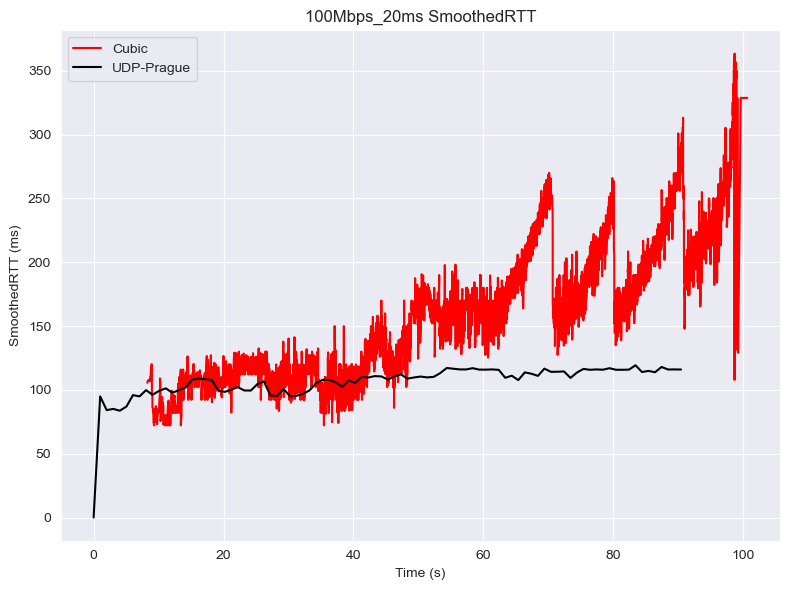


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_100Mbps_0ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_0ms_ecn_udp_dctcp_src2.siftr.log


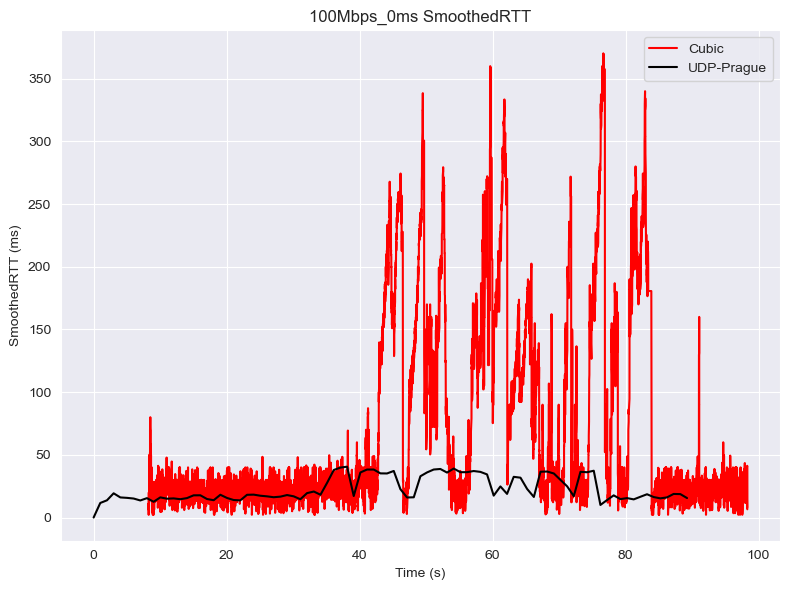


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_10Mbps_10ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_10Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


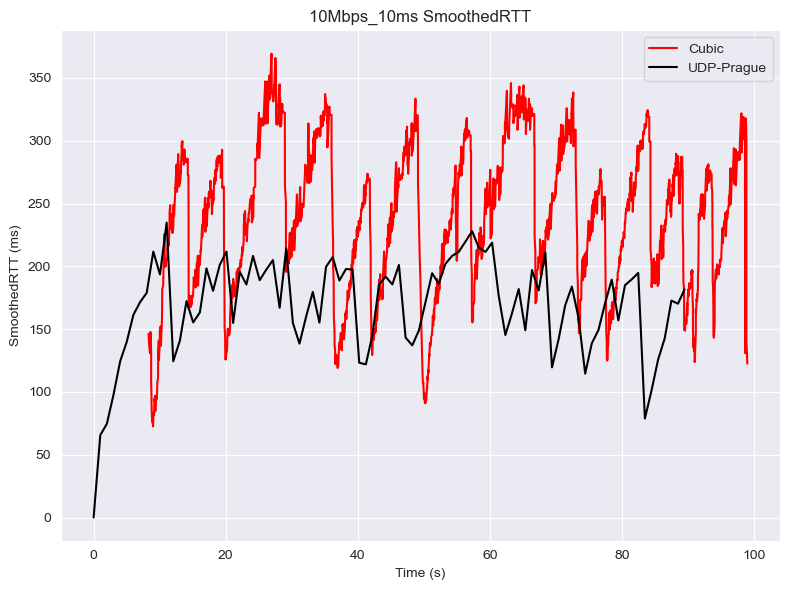


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_5Mbps_5ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_5ms_ecn_udp_dctcp_src2.siftr.log


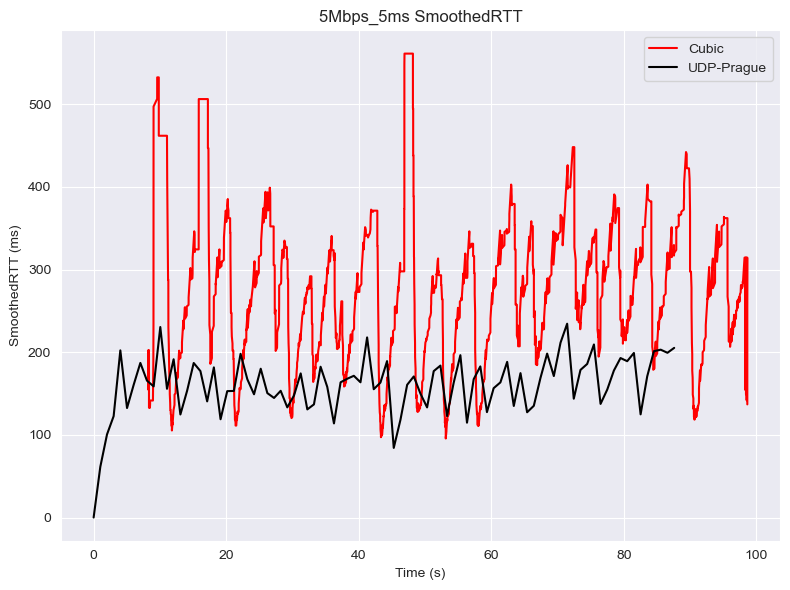


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_20Mbps_5ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_5ms_ecn_udp_dctcp_src2.siftr.log


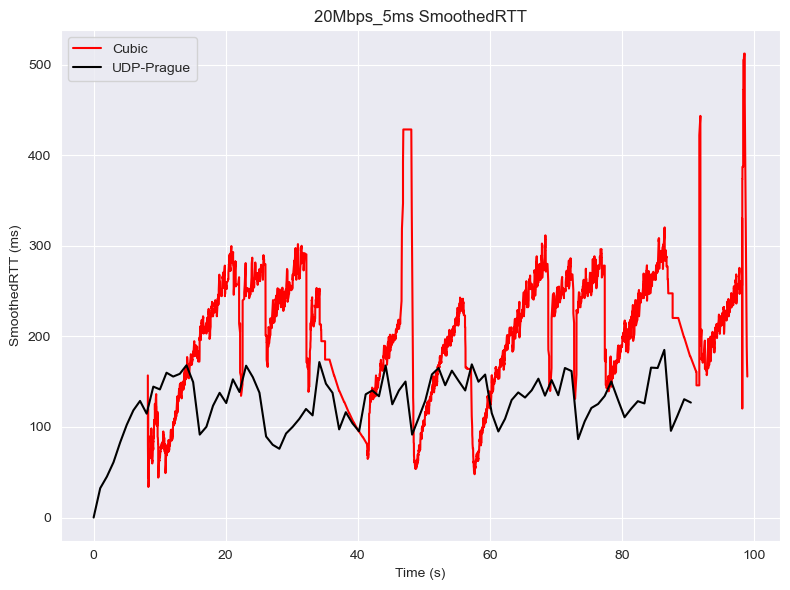


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_150Mbps_5ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_150Mbps_5ms_ecn_udp_dctcp_src2.siftr.log


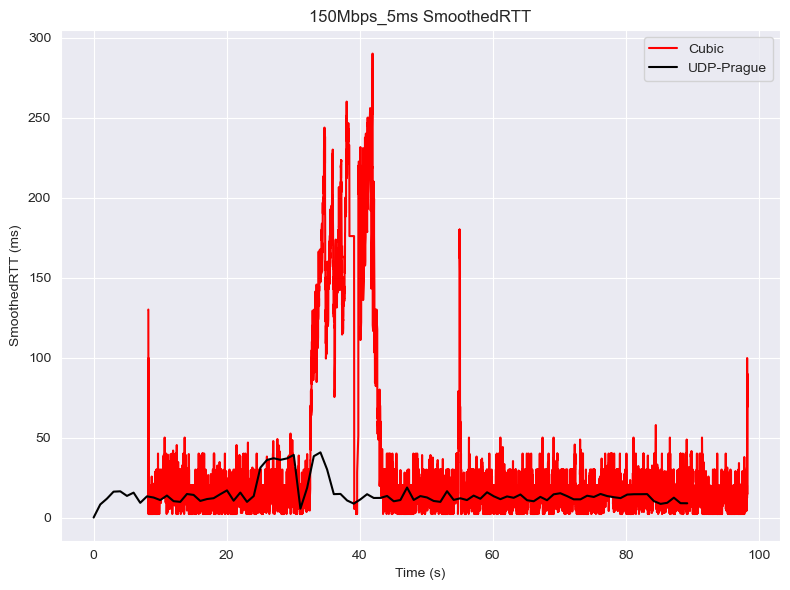


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_100Mbps_10ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_100Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


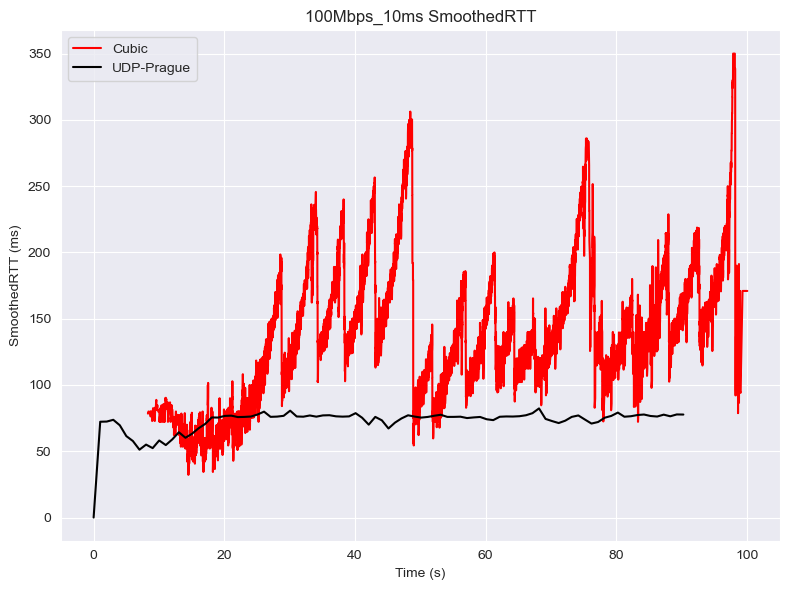


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_5Mbps_20ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_20ms_ecn_udp_dctcp_src2.siftr.log


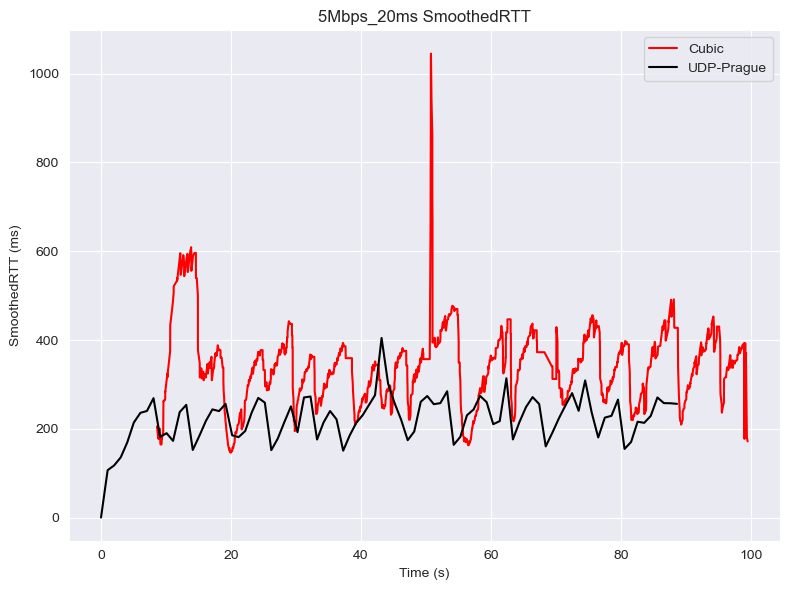


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_5Mbps_0ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_0ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_5Mbps_0ms_ecn_udp_dctcp_src2.siftr.log


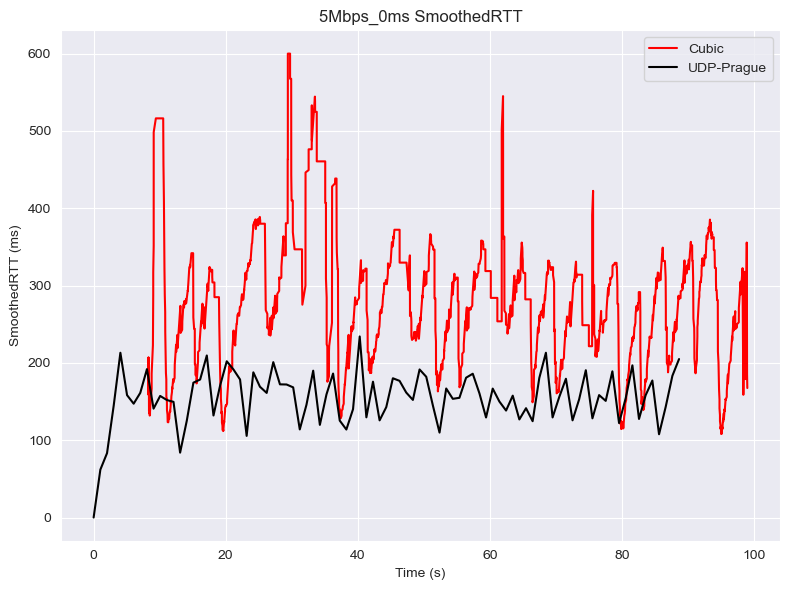


Start New Scenario
utf ../data/udp_data_2025-04-27/server_data\udp_prague_receiver_1_dualpi2_20Mbps_20ms_ecn_udp.txt
ttf ../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log
../data/udp_data_2025-04-27/client2_data\1_dualpi2_20Mbps_20ms_ecn_udp_dctcp_src2.siftr.log


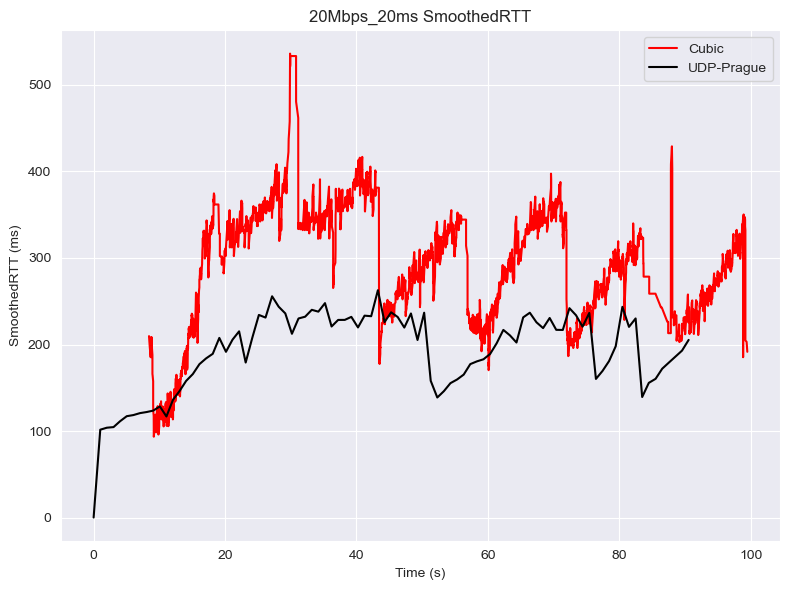

In [6]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]

    print()
    print("Start New Scenario")
    # print(scenario)
    # print(unique_scenarios_dict_v2[scenario])

    print("utf", unique_scenarios_dict_v2[scenario][4])
    print("ttf", unique_scenarios_dict_v2[scenario][13])

    


    udp_traffic = unique_scenarios_dict_v2[scenario][4]
    utf = extract_udp_prague_to_dataframe(udp_traffic)

    tcp_traffic = unique_scenarios_dict_v2[scenario][13]
    ttf = get_dataframe_from_filepath(tcp_traffic)
    ttf = ttf[ttf['ForeignPort'] == "5102"]

    utf.rename(columns={'RTT_ms': 'SmoothedRTT'}, inplace=True)



        # Define paths
    paths = {
        "Cubic": ttf,
        "UDP-Prague": utf
    }

    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )


    # # Extract the second part of the float time (i.e., the integer part as seconds)
    # ttf['Second'] = ttf['Time'].apply(lambda x: int(x))

    # # Group by 'Second' and calculate the median for the 'RTT' column
    # ttf_grouped = ttf.groupby('Second')['SmoothedRTT'].median().reset_index()


    #     # Extract the second part of the float time (i.e., the integer part as seconds)
    # utf['Second'] = utf['Time'].apply(lambda x: int(x))

    # # Group by 'Second' and calculate the median for the 'RTT' column
    # utf_grouped = utf.groupby('Second')['RTT_ms'].median().reset_index()

    # # ttf_grouped = ttf.groupby('Time')['SmoothedRTT'].median().reset_index()
    # # utf_grouped = utf.groupby('Time')['RTT_ms'].median().reset_index()

    # Plotting both
    # plt.figure(figsize=(12, 6))
    # plt.plot(ttf['Time'], ttf['SmoothedRTT'], label='TCP NewReno', marker='x',color='red')
    # plt.plot(utf['Time'], utf['RTT_ms'], label='UDP-Prague', marker='x',color='black')
    # plt.xlabel('Time (s)')
    # plt.ylabel('RTT (ms)')
    # plt.title('TCP NewReno vs UDP-Prague RTT Comparison')
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

    # print("utf")


In [7]:
ttf['Time'].head(40)

73     8.429433
74     8.429876
76     8.540225
77     8.540409
80     8.677793
81     8.743301
82     8.743384
85     8.829682
86     8.830229
87     8.830319
88     8.830369
89     8.830423
90     8.830475
91     8.830526
92     8.830579
93     8.830631
94     8.830677
96     8.862671
98     8.949779
99     8.949846
100    8.949893
101    8.949941
103    8.949997
104    8.950037
105    8.950076
106    8.950115
108    8.950155
109    8.950194
110    8.950233
111    8.950272
113    8.950323
114    8.950395
115    8.950440
116    8.950487
118    8.981355
119    8.981401
120    8.981426
121    8.981454
123    9.060305
124    9.060429
Name: Time, dtype: float64

In [8]:
ttf

,Direction,Time,LocalIP,LocalPort,ForeignIP,ForeignPort,SlowStartThreshold,CongestionWindow,BandwidthControlledWindow,SendingWindow,...,TCPFlags,RetransmissionTimeout,SocketSendBufferSize,SocketSendBufferBytes,SocketReceiveBufferSize,SocketReceiveBufferBytes,UnacknowledgedBytes,ReassemblyQueue,Flowid,Flowtype
73,o,8.429433,192.168.1.3,12790,192.168.3.2,5102,71085,14480,290,65535,...,993,800000,33580,0,65700,0,0,0,1396187481,63
74,o,8.429876,192.168.1.3,12790,192.168.3.2,5102,71085,14480,290,65535,...,996,800000,33580,37,65700,0,0,0,1396187481,63
76,o,8.540225,192.168.1.3,12790,192.168.3.2,5102,71085,14517,1314,65728,...,996,790000,33580,4,65700,0,0,0,1396187481,63
77,o,8.540409,192.168.1.3,12790,192.168.3.2,5102,71085,14517,1314,65728,...,33764,790000,33580,128,65700,0,4,0,1396187481,63
80,o,8.677793,192.168.1.3,12790,192.168.3.2,5102,71085,14645,1314,65728,...,997,780000,33580,0,65700,0,0,0,1396187481,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37033,o,99.186937,192.168.1.3,12790,192.168.3.2,5102,71085,14481,1314,65728,...,33764,850000,33580,316,65700,0,4,0,1396187481,63
37127,o,99.369353,192.168.1.3,12790,192.168.3.2,5102,71085,14797,1314,65728,...,997,750000,33580,0,65700,335,0,0,1396187481,63
37129,o,99.369541,192.168.1.3,12790,192.168.3.2,5102,71085,14797,1314,65728,...,996,750000,33580,1,65700,0,0,0,1396187481,63
37130,o,99.369581,192.168.1.3,12790,192.168.3.2,5102,71085,14797,1314,65728,...,33764,750000,33580,1,65700,0,1,0,1396187481,63


In [9]:
utf

,Time,Rcvd_Mbps,Sent_Mbps,SmoothedRTT,Mark_pct,Mark_Marked,Mark_Total,Lost_pct,Lost_Lost,Lost_Total
0,0.00,0.001,0.000,0.000,0.0,0,1,0.0,0,1
1,1.01,0.585,0.010,101.534,0.0,0,59,0.0,0,59
2,2.01,1.421,0.022,103.815,0.0,0,127,0.0,0,127
3,3.03,2.199,0.035,104.532,0.0,0,200,0.0,0,200
4,4.03,2.822,0.044,111.321,0.0,0,252,0.0,0,252
...,...,...,...,...,...,...,...,...,...,...
86,86.53,6.330,0.099,172.056,0.0,0,573,0.0,0,573
87,87.53,6.395,0.100,179.029,0.0,0,571,0.0,0,571
88,88.53,6.360,0.100,185.932,0.0,0,568,0.0,0,568
89,89.54,6.324,0.099,192.912,0.0,0,570,0.0,0,570


In [10]:
ttf['SmoothedRTT']

73       209.687
74       209.687
76       197.500
77       197.500
80       185.312
          ...   
37033    204.687
37127    203.125
37129    203.125
37130    203.125
37144    191.562
Name: SmoothedRTT, Length: 24516, dtype: float64

In [11]:
utf.columns

Index(['Time', 'Rcvd_Mbps', 'Sent_Mbps', 'SmoothedRTT', 'Mark_pct',
       'Mark_Marked', 'Mark_Total', 'Lost_pct', 'Lost_Lost', 'Lost_Total'],
      dtype='object')

In [12]:
ttf.columns

Index(['Direction', 'Time', 'LocalIP', 'LocalPort', 'ForeignIP', 'ForeignPort',
       'SlowStartThreshold', 'CongestionWindow', 'BandwidthControlledWindow',
       'SendingWindow', 'ReceiveWindow', 'SendingWindowScalingFactor',
       'ReceiveWindowScalingFactor', 'TCPFiniteStateMachine',
       'MaximumSegmentSize', 'SmoothedRTT', 'SACKEnabled', 'TCPFlags',
       'RetransmissionTimeout', 'SocketSendBufferSize',
       'SocketSendBufferBytes', 'SocketReceiveBufferSize',
       'SocketReceiveBufferBytes', 'UnacknowledgedBytes', 'ReassemblyQueue',
       'Flowid', 'Flowtype'],
      dtype='object')

In [13]:
import re
import csv
import sys
import os

def extract_udp_prague_log_to_csv(input_txt_file, output_csv_file=None):
    if not os.path.exists(input_txt_file):
        print(f"Error: File '{input_txt_file}' not found.")
        return

    # Set default output filename if not provided
    if output_csv_file is None:
        output_csv_file = os.path.splitext(input_txt_file)[0] + "_parsed.csv"

    # Regex pattern for extracting log data
    pattern = re.compile(
        r"\[RECVER\]: ([\d.]+) sec, Rcvd: ([\d.]+) Mbps, Sent: ([\d.]+) Mbps, "
        r"RTT: ([\d.]+) ms, Mark: ([\d.\-]+)%\((\-?\d+)/(\d+)\), Lost: ([\d.\-]+)%\((\-?\d+)/(\d+)\)"
    )

    extracted_data = []

    with open(input_txt_file, "r") as infile:
        for line in infile:
            match = pattern.search(line)
            if match:
                extracted_data.append(match.groups())

    headers = [
        "Time(sec)", "Rcvd(Mbps)", "Sent(Mbps)", "RTT(ms)",
        "Mark(%)", "MarkMarked", "MarkTotal", "Lost(%)", "LostLost", "LostTotal"
    ]

    with open(output_csv_file, "w", newline="") as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(headers)
        writer.writerows(extracted_data)

    print(f"✅ Data extracted to: {output_csv_file}")

input_file = input_file
output_file = "output_file_parsed.csv"  # Default output file name
extract_udp_prague_log_to_csv(input_file, output_file)


NameError: name 'input_file' is not defined